<a href="https://colab.research.google.com/github/CalculatedContent/xgboost2ww/blob/main/notebooks/XGBoost2WWCovertypeHyperparameterSweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# xgboost2ww Covertype Hyperparameter Sweep (Underfit → Tuned → Mild Overfit)

## What this notebook does
- **Dataset**: UCI/Kaggle-style **Forest CoverType** via `sklearn.datasets.fetch_covtype` (581,012 rows, 54 features, 7 classes). Multiclass accuracy is expected to be lower than 90%+ binary examples.
- **Multiclass objective**: XGBoost `objective='multi:softprob'` with `num_class=7`, evaluating `mlogloss` and `merror`.
- **Split protocol**: deterministic stratified 80/20 train-test split (`RNG=123`) plus a stratified validation split from train for early stopping.
- **Runtime controls**: configurable `SAMPLE_N`, `NFOLDS_SWEEP`, `T_POINTS_SWEEP` and optional heavier best-model verification settings so Colab runs remain practical.
- **xgboost2ww multiclass mode**: main sweep uses `multiclass='stack'` with `return_type='torch'` for a single WeightWatcher-friendly matrix; optional representative configs use `multiclass='per_class'` with `return_type='numpy'` because per-class + torch is unsupported.
- **WeightWatcher metrics**: `alpha`, `rand_num_spikes` (all configs, always `randomize=True`), and optional `detX` for representative configs only.
- **Sweep strategy**: Stage A regime sweep (underfit/tuned/overfit seeds + perturbations), Stage B local refinement around top configs.
- **Expected qualitative pattern**: as in Adult/Spambase, better-generalizing models often have healthier spectral structure (alpha nearer 2, fewer traps), while underfit tends to larger alpha and overfit/unstable regimes often show alpha < 2 and/or more traps.
- **Reproducibility and persistence**: fixed seeds, explicit requested vs achieved boosting rounds, checkpointed CSV/plots under a Covertype-specific folder.

> We expect to observe the same **qualitative** alpha/performance pattern as binary notebooks, but absolute accuracy values differ because this is a larger 7-class multiclass task.


## Google Drive checkpoint locations (duplicated here for run notes)
- **Checkpoint root path:** `/content/drive/MyDrive/xgboost2ww_checkpoints`
- **This run folder path:** `/content/drive/MyDrive/xgboost2ww_checkpoints/covertype_hparam_sweep`
- **Results CSV path:** `/content/drive/MyDrive/xgboost2ww_checkpoints/covertype_hparam_sweep/covertype_hyperparameter_sweep_results.csv`

When running outside Colab, the notebook uses `./checkpoints/covertype_hparam_sweep/` as the local fallback.


In [1]:
from pathlib import Path
import os

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

CHECKPOINT_ROOT_COLAB = Path('/content/drive/MyDrive/xgboost2ww_checkpoints')
CHECKPOINT_ROOT_LOCAL = Path('./checkpoints')
EXPERIMENT_NAME = 'covertype_hparam_sweep'
OUTPUT_FILENAME = 'covertype_hyperparameter_sweep_results.csv'

if IN_COLAB:
    drive.mount('/content/drive')
    CHECKPOINT_ROOT = CHECKPOINT_ROOT_COLAB
else:
    CHECKPOINT_ROOT = CHECKPOINT_ROOT_LOCAL

CHECKPOINT_DIR = CHECKPOINT_ROOT / EXPERIMENT_NAME
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_RESULTS_CSV = CHECKPOINT_DIR / OUTPUT_FILENAME

print('IN_COLAB:', IN_COLAB)
print('CHECKPOINT_DIR:', CHECKPOINT_DIR)
print('CHECKPOINT_RESULTS_CSV:', CHECKPOINT_RESULTS_CSV)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB: True
CHECKPOINT_DIR: /content/drive/MyDrive/xgboost2ww_checkpoints/covertype_hparam_sweep
CHECKPOINT_RESULTS_CSV: /content/drive/MyDrive/xgboost2ww_checkpoints/covertype_hparam_sweep/covertype_hyperparameter_sweep_results.csv


In [2]:
# Optional install cell (useful in Colab)
!pip -q install xgboost weightwatcher xgboost2ww scikit-learn pandas matplotlib


## Imports and reproducibility controls


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype, fetch_openml
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, log_loss, balanced_accuracy_score, f1_score

import xgboost as xgb
import weightwatcher as ww
from xgboost2ww import convert, to_linear_layer


In [ ]:
RNG = 123
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.20

# Runtime knobs (safe defaults for Colab)
USE_SAMPLING = True
SAMPLE_N = 120_000
NFOLDS_SWEEP = 3
NFOLDS_BEST = 5
T_POINTS_SWEEP = 32
T_POINTS_BEST = 64
RUN_EXPENSIVE_BEST_VERIFICATION = False

# Checkpoint/resume controls
CHECKPOINT_SAVE_EVERY = 1
RESTART_EXPERIMENT = False  # set True to ignore prior CSV and rerun everything from scratch

MULTICLASS_MODE_MAIN = 'stack'  # 'stack' preferred; fallback to 'avg' if memory is tight
W_MATRIX_NAME = 'W7'

# Increase WeightWatcher matrix-size cap for large stacked multiclass matrices
WW_MAX_N = 800000


## Load Covertype with deterministic fallback and run sanity checks


In [ ]:
try:
    data = fetch_covtype()
    X, y = data.data, data.target
    loader_used = 'fetch_covtype'
except Exception:
    data = fetch_openml(name='covertype', version=3, as_frame=False)
    X, y = data.data, data.target
    loader_used = 'fetch_openml(covertype)'

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y)
if y.dtype.kind in {'U', 'S', 'O'}:
    y = y.astype(int)
y = y.astype(np.int64)
if y.min() == 1:
    y = y - 1

n_classes = int(np.unique(y).shape[0])
print('loader:', loader_used)
print('X.shape:', X.shape, 'y.shape:', y.shape)
print('n_classes:', n_classes)

class_counts = pd.Series(y).value_counts().sort_index()
print('counts per class:')
print(class_counts)

if USE_SAMPLING and SAMPLE_N < len(y):
    sss = StratifiedShuffleSplit(n_splits=1, train_size=SAMPLE_N, random_state=RNG)
    idx, _ = next(sss.split(X, y))
    X = X[idx]
    y = y[idx]
    print(f'Applied stratified sample: SAMPLE_N={SAMPLE_N}, new shape={X.shape}')


In [ ]:
idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size=TEST_SIZE, random_state=RNG, stratify=y
)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

idx_tr, idx_val = train_test_split(
    np.arange(len(y_train)), test_size=VAL_SIZE_WITHIN_TRAIN, random_state=RNG, stratify=y_train
)

print('Train/Test sizes:', X_train.shape, X_test.shape)
print('Train class counts:\n', pd.Series(y_train).value_counts().sort_index().to_string())
print('Test class counts:\n', pd.Series(y_test).value_counts().sort_index().to_string())
print('Inner train/val sizes:', len(idx_tr), len(idx_val))


## Helpers: train/evaluate + xgboost2ww + WeightWatcher (graceful degradation)


In [ ]:
def fit_eval_config(tag, cfg, t_points=T_POINTS_SWEEP, run_detx=False):
    params = dict(
        objective='multi:softprob',
        num_class=n_classes,
        eval_metric=['mlogloss', 'merror'],
        tree_method='hist',
        seed=RNG,
        verbosity=0,
    )
    params.update(cfg)
    num_boost_round = int(params.pop('num_boost_round', 2000))
    early_stopping_rounds = params.pop('early_stopping_rounds', 100)

    dtr = xgb.DMatrix(X_train[idx_tr], label=y_train[idx_tr])
    dva = xgb.DMatrix(X_train[idx_val], label=y_train[idx_val])
    dtrain_full = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    evals_result = {}
    booster = xgb.train(
        params=params,
        dtrain=dtr,
        num_boost_round=num_boost_round,
        evals=[(dtr, 'tr'), (dva, 'va')],
        early_stopping_rounds=early_stopping_rounds,
        evals_result=evals_result,
        verbose_eval=False,
    )

    best_iteration = int(getattr(booster, 'best_iteration', num_boost_round - 1))
    train_proba = booster.predict(dtrain_full, iteration_range=(0, best_iteration + 1))
    test_proba = booster.predict(dtest, iteration_range=(0, best_iteration + 1))

    train_pred = np.argmax(train_proba, axis=1)
    test_pred = np.argmax(test_proba, axis=1)

    row = {
        'tag': tag,
        'num_boost_round_requested': num_boost_round,
        'best_iteration': best_iteration,
        'train_acc': accuracy_score(y_train, train_pred),
        'test_acc': accuracy_score(y_test, test_pred),
        'train_bal_acc': balanced_accuracy_score(y_train, train_pred),
        'test_bal_acc': balanced_accuracy_score(y_test, test_pred),
        'test_macro_f1': f1_score(y_test, test_pred, average='macro'),
        'train_mlogloss': log_loss(y_train, train_proba, labels=np.arange(n_classes)),
        'test_mlogloss': log_loss(y_test, test_proba, labels=np.arange(n_classes)),
        'multiclass_mode': MULTICLASS_MODE_MAIN,
        'alpha': np.nan,
        'rand_num_spikes': np.nan,
        'detX_val': np.nan,
        'ww_note': '',
    }
    for k, v in cfg.items():
        row[f'hp_{k}'] = v

    try:
        model_ww = convert(booster, X_train, y_train, multiclass=MULTICLASS_MODE_MAIN, return_type='torch')
        watcher = ww.WeightWatcher(model=model_ww, log_level='ERROR')
        details = watcher.analyze(
            randomize=True,
            min_evals=10,
            max_evals=200,
            mp_fit=False,
            plot=False,
            savefig=False,
            detX=run_detx,
            max_N=WW_MAX_N,
        )
        details = pd.DataFrame(details)
        if 'alpha' in details.columns:
            row['alpha'] = float(details['alpha'].dropna().iloc[0]) if details['alpha'].notna().any() else np.nan
        if 'rand_num_spikes' in details.columns:
            row['rand_num_spikes'] = float(details['rand_num_spikes'].dropna().iloc[0]) if details['rand_num_spikes'].notna().any() else np.nan
        if run_detx and 'detX_val' in details.columns and details['detX_val'].notna().any():
            row['detX_val'] = float(details['detX_val'].dropna().iloc[0])
    except Exception as e:
        row['ww_note'] = f'skipped/failed: {type(e).__name__}: {e}'
        # automatic fallback: lower t_points via avg mode
        try:
            model_ww = convert(booster, X_train, y_train, multiclass='avg', return_type='torch')
            watcher = ww.WeightWatcher(model=model_ww, log_level='ERROR')
            details = pd.DataFrame(watcher.analyze(randomize=True, min_evals=10, max_evals=120, mp_fit=False, plot=False, savefig=False, max_N=WW_MAX_N))
            row['multiclass_mode'] = 'avg'
            if 'alpha' in details.columns and details['alpha'].notna().any():
                row['alpha'] = float(details['alpha'].dropna().iloc[0])
            if 'rand_num_spikes' in details.columns and details['rand_num_spikes'].notna().any():
                row['rand_num_spikes'] = float(details['rand_num_spikes'].dropna().iloc[0])
            row['ww_note'] += ' | fallback avg mode applied'
        except Exception as e2:
            row['ww_note'] += f' | fallback failed: {type(e2).__name__}: {e2}'

    print(f"[{tag}] requested={num_boost_round} best_iteration={best_iteration} train_acc={row['train_acc']:.4f} test_acc={row['test_acc']:.4f} alpha={row['alpha']}")
    return row, booster


## Debug cell: single-model convert + WeightWatcher deep diagnostics

Use this when `alpha` is NaN or conversion/WW unexpectedly fails. It trains one selected config, runs `xgboost2ww.convert`, and then runs WeightWatcher with `plot=True` plus extra diagnostics.

Debug config: U1 {'max_depth': 2, 'eta': 0.3, 'num_boost_round': 150, 'early_stopping_rounds': 40, 'min_child_weight': 20, 'gamma': 5, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_lambda': 50, 'reg_alpha': 0}
best_iteration: 147 requested: 150
debug test_acc: 0.7439166666666667
debug test_mlogloss: 0.585806952159488
Converting with multiclass= stack return_type= torch


INFO:weightwatcher:

python      version 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy       version 2.0.2
torch version 2.10.0+cu128
INFO:weightwatcher:SET MODEL: None, None
INFO:weightwatcher:SET MODEL: Sequential(
  (0): Linear(in_features=150, out_features=672000, bias=False)
), None
INFO:weightwatcher:params {'glorot_fix': False, 'normalize': False, 'conv2d_norm': True, 'randomize': True, 'savedir': 'ww-img', 'savefig': False, 'rescale': True, 'plot': True, 'deltaEs': False, 'intra': False, 'channels': None, 'fft': False, 'conv2d_fft': False, 'ww2x': False, 'pool': True, 'vectors': False, 'smooth': None, 'stacked': False, 'svd_method': 'fast', 'fix_fingers': False, 'fit': 'power_law', 'MAX_FINGERS': 10, 'finger_thresh': 1.0, 'sparsify': True, 'detX': True, 'mp_fit': False, 'min_evals': 10, 'max_evals': 200, 'max_N': 800000, 'tolerance': 1e-06, 'layer_ids_start': 0, 'add_biases': False, 'xmin_max': None, 'pl_package': 'ww', 'xmax': None, 'peft': False, 'inverse': False, 

convert() success. type = <class 'torch.nn.modules.container.Sequential'>
torch module count: 2
layers with weight attr: 1
  layer[0] weight shape: (672000, 150)


INFO:weightwatcher:Running powerlaw.Fit no xmin, xmax=None. distribution=power_law pl_package=ww
INFO:weightwatcher:PL FIT running NEW power law method


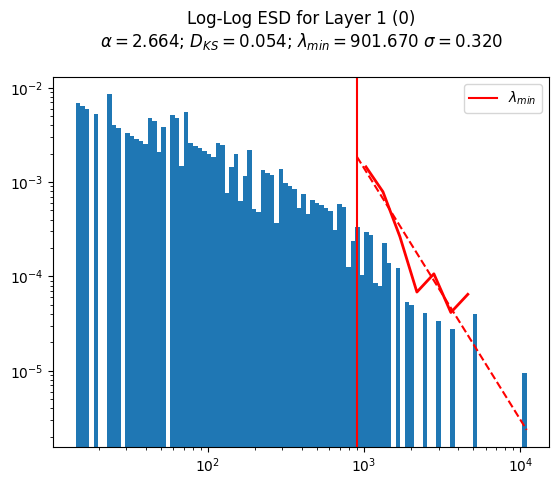

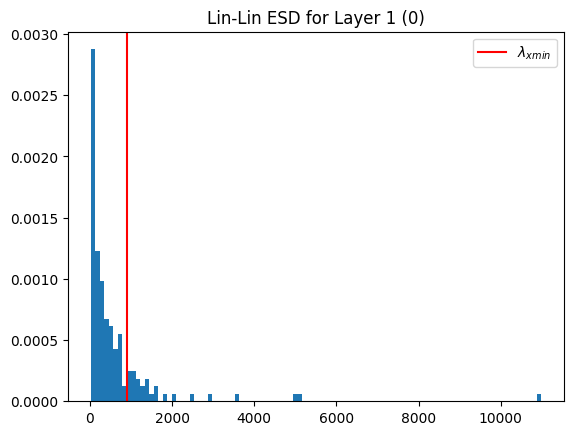

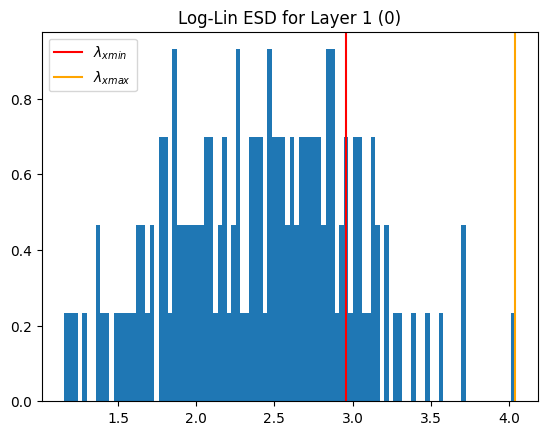

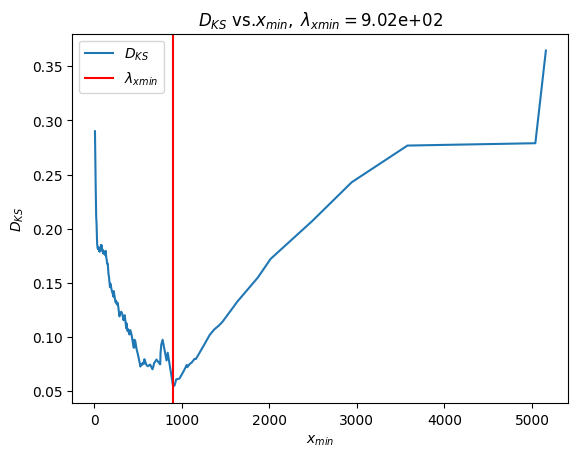

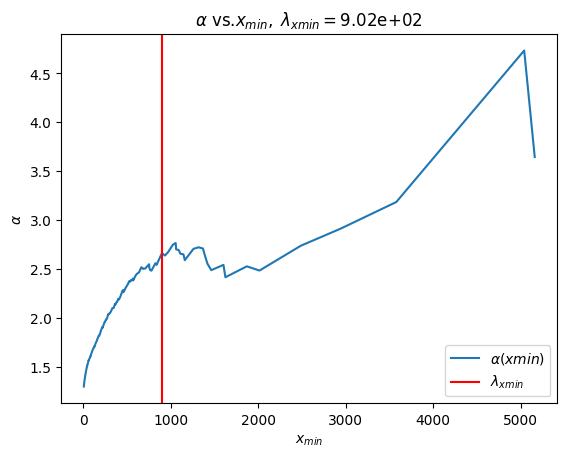

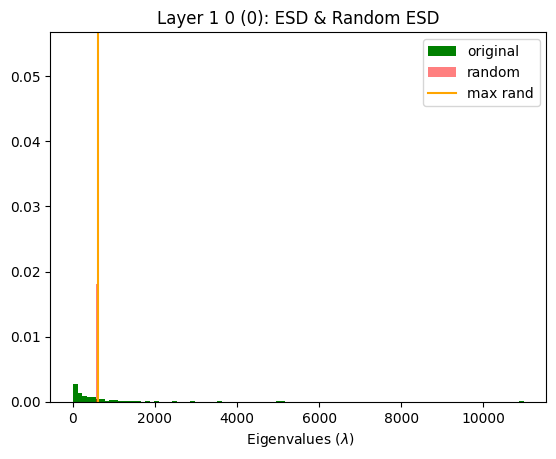

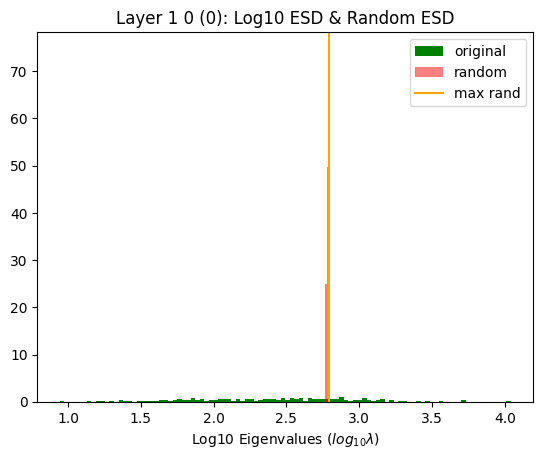

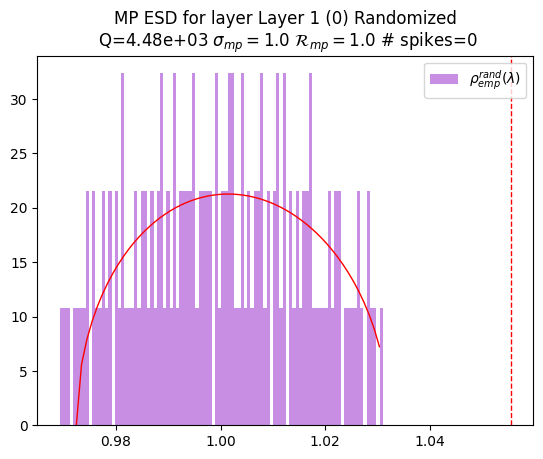

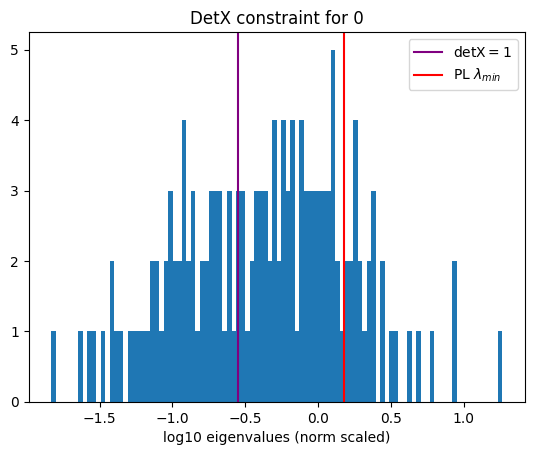

WW analyze rows: 1


,layer_id,name,N,M,alpha,rand_num_spikes,detX_val,status
0,1,0,672000,150,2.664018,0,167.990234,success


alpha describe:
count    1.000000
mean     2.664018
std           NaN
min      2.664018
25%      2.664018
50%      2.664018
75%      2.664018
max      2.664018
Name: alpha, dtype: float64
alpha NaN rows: 0

Fallback convert smoke test: multiclass=avg


INFO:weightwatcher: __init__: Sequential(
  (0): Linear(in_features=150, out_features=96000, bias=False)
), None


  success, rows= 0 alpha_non_nan= n/a

Fallback convert smoke test: multiclass=per_class


,class_id,rows,alpha_non_nan
0,0,0,0
1,1,0,0
2,2,0,0
3,3,0,0
4,4,0,0
5,5,0,0
6,6,0,0


<Figure size 640x480 with 0 Axes>

In [8]:
# Debug one model end-to-end: train -> convert -> WeightWatcher (plot=True)

DEBUG_TAG = 'U1'  # quick presets below
DEBUG_MULTICLASS = 'stack'  # try: 'stack', 'avg', 'per_class'
DEBUG_RETURN_TYPE = 'torch'  # for stack/avg use 'torch'
DEBUG_PRESETS = {
    'U1': dict(max_depth=2, eta=0.3, num_boost_round=150, early_stopping_rounds=40, min_child_weight=20, gamma=5, subsample=0.6, colsample_bytree=0.6, reg_lambda=50, reg_alpha=0),
    'T1': dict(max_depth=8, eta=0.08, num_boost_round=1200, early_stopping_rounds=80, min_child_weight=2, gamma=0, subsample=0.8, colsample_bytree=0.8, reg_lambda=10, reg_alpha=0),
    'O1': dict(max_depth=12, eta=0.15, num_boost_round=1200, early_stopping_rounds=100, min_child_weight=1, gamma=0, subsample=1.0, colsample_bytree=1.0, reg_lambda=0.5, reg_alpha=0),
}

assert DEBUG_TAG in DEBUG_PRESETS, f'{DEBUG_TAG} not in DEBUG_PRESETS'
debug_cfg = dict(DEBUG_PRESETS[DEBUG_TAG])
print('Debug config:', DEBUG_TAG, debug_cfg)

# 1) Train a single model with deterministic split used above
dbg_params = dict(
    objective='multi:softprob',
    num_class=n_classes,
    eval_metric=['mlogloss', 'merror'],
    tree_method='hist',
    seed=RNG,
    verbosity=1,
)
dbg_params.update(debug_cfg)
num_boost_round = int(dbg_params.pop('num_boost_round', 200))
early_stopping_rounds = int(dbg_params.pop('early_stopping_rounds', 50))

dtr = xgb.DMatrix(X_train[idx_tr], label=y_train[idx_tr])
dva = xgb.DMatrix(X_train[idx_val], label=y_train[idx_val])
dtest = xgb.DMatrix(X_test, label=y_test)

dbg_evals_result = {}
dbg_booster = xgb.train(
    params=dbg_params,
    dtrain=dtr,
    num_boost_round=num_boost_round,
    evals=[(dtr, 'tr'), (dva, 'va')],
    early_stopping_rounds=early_stopping_rounds,
    evals_result=dbg_evals_result,
    verbose_eval=False,
)

best_iteration = int(getattr(dbg_booster, 'best_iteration', num_boost_round - 1))
print('best_iteration:', best_iteration, 'requested:', num_boost_round)

# quick predictive sanity check
dbg_proba = dbg_booster.predict(dtest, iteration_range=(0, best_iteration + 1))
dbg_pred = np.argmax(dbg_proba, axis=1)
print('debug test_acc:', accuracy_score(y_test, dbg_pred))
print('debug test_mlogloss:', log_loss(y_test, dbg_proba, labels=np.arange(n_classes)))

# 2) Convert with xgboost2ww and inspect converter output
print('Converting with multiclass=', DEBUG_MULTICLASS, 'return_type=', DEBUG_RETURN_TYPE)
try:
    dbg_model_ww = convert(
        dbg_booster,
        X_train,
        y_train,
        multiclass=DEBUG_MULTICLASS,
        return_type=DEBUG_RETURN_TYPE,
    )
    print('convert() success. type =', type(dbg_model_ww))
except Exception as e:
    print('convert() failed:', type(e).__name__, e)
    raise

# Optional structural introspection to catch malformed converted layers
try:
    if hasattr(dbg_model_ww, 'modules'):
        layers = [m for m in dbg_model_ww.modules()]
        print('torch module count:', len(layers))
        linear_like = [m for m in layers if hasattr(m, 'weight')]
        print('layers with weight attr:', len(linear_like))
        for i, lyr in enumerate(linear_like[:10]):
            w = getattr(lyr, 'weight', None)
            if w is not None:
                print(f'  layer[{i}] weight shape:', tuple(w.shape))
except Exception as e:
    print('Model structure introspection warning:', type(e).__name__, e)

# 3) WeightWatcher with plot=True and extra debug flags
try:
    dbg_watcher = ww.WeightWatcher(model=dbg_model_ww, log_level='INFO')
    dbg_details = dbg_watcher.analyze(
        randomize=True,
        min_evals=10,
        max_evals=200,
        mp_fit=False,
        plot=True,
        savefig=False,
        detX=True,
        max_N=WW_MAX_N,
    )
    dbg_details = pd.DataFrame(dbg_details)
    print('WW analyze rows:', len(dbg_details))
    display_cols = [c for c in ['layer_id', 'name', 'N', 'M', 'alpha', 'rand_num_spikes', 'detX_val', 'status'] if c in dbg_details.columns]
    display(dbg_details[display_cols] if display_cols else dbg_details.head())

    if 'alpha' in dbg_details:
        print('alpha describe:')
        print(dbg_details['alpha'].describe(include='all'))
        print('alpha NaN rows:', int(dbg_details['alpha'].isna().sum()))
except Exception as e:
    print('WeightWatcher analyze failed:', type(e).__name__, e)
    raise

# 4) If stack fails, quick fallback checks for convert-specific behavior
if DEBUG_MULTICLASS == 'stack':
    print('\nFallback convert smoke test: multiclass=avg')
    try:
        alt_model = convert(dbg_booster, X_train, y_train, multiclass='avg', return_type='torch')
        alt_details = pd.DataFrame(
            ww.WeightWatcher(model=alt_model, log_level='ERROR').analyze(
                randomize=True,
                min_evals=10,
                max_evals=120,
                mp_fit=False,
                plot=True,
                savefig=False,
                max_N=WW_MAX_N,
            )
        )
        print('  success, rows=', len(alt_details), 'alpha_non_nan=', int(alt_details['alpha'].notna().sum()) if 'alpha' in alt_details else 'n/a')
    except Exception as e:
        print('  failed:', type(e).__name__, e)

    print('\nFallback convert smoke test: multiclass=per_class')
    try:
        alt_models = convert(dbg_booster, X_train, y_train, multiclass='per_class', return_type='numpy')
        per_class_rows = []
        for class_id, Wk in sorted(alt_models.items()):
            class_model = to_linear_layer(Wk)
            import torch
            class_seq = torch.nn.Sequential(class_model)
            class_details = pd.DataFrame(
                ww.WeightWatcher(model=class_seq, log_level='ERROR').analyze(
                    randomize=True,
                    min_evals=10,
                    max_evals=120,
                    mp_fit=False,
                    plot=False,
                    savefig=False,
                    max_N=WW_MAX_N,
                )
            )
            per_class_rows.append({
                'class_id': class_id,
                'rows': len(class_details),
                'alpha_non_nan': int(class_details['alpha'].notna().sum()) if 'alpha' in class_details else 0,
            })
        display(pd.DataFrame(per_class_rows))
    except Exception as e:
        print('  failed:', type(e).__name__, e)


## Best model section (strong tuned candidate)


In [ ]:
best_cfg = dict(
    max_depth=10,
    eta=0.05,
    num_boost_round=6000,
    early_stopping_rounds=150,
    min_child_weight=1,
    gamma=0,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=5,
    reg_alpha=0.5,
)

if RESTART_EXPERIMENT:
    checkpoint_df = pd.DataFrame()
    print('RESTART_EXPERIMENT=True -> ignoring existing checkpoint file')
elif CHECKPOINT_RESULTS_CSV.exists():
    checkpoint_df = pd.read_csv(CHECKPOINT_RESULTS_CSV)
    print(f'Loaded checkpoint with {len(checkpoint_df)} rows from {CHECKPOINT_RESULTS_CSV}')
else:
    checkpoint_df = pd.DataFrame()
    print('No checkpoint found yet. Starting fresh.')

checkpoint_by_tag = {}
if not checkpoint_df.empty and 'tag' in checkpoint_df.columns:
    checkpoint_by_tag = checkpoint_df.drop_duplicates(subset=['tag'], keep='last').set_index('tag').to_dict(orient='index')

if 'BEST' in checkpoint_by_tag:
    best_row = checkpoint_by_tag['BEST']
    best_booster = None
    print('BEST already present in checkpoint; skipping retrain for BEST.')
else:
    best_row, best_booster = fit_eval_config('BEST', best_cfg, t_points=T_POINTS_BEST, run_detx=True)
    checkpoint_df = pd.concat([checkpoint_df, pd.DataFrame([best_row])], ignore_index=True)
    checkpoint_df = checkpoint_df.drop_duplicates(subset=['tag'], keep='last')
    checkpoint_df.to_csv(CHECKPOINT_RESULTS_CSV, index=False)
    checkpoint_by_tag['BEST'] = best_row
    print('Saved:', CHECKPOINT_RESULTS_CSV)

pd.DataFrame([best_row])


[BEST] requested=6000 best_iteration=1304 train_acc=0.9855 test_acc=0.9271 alpha=1.9214604016252392


,tag,num_boost_round_requested,best_iteration,train_acc,test_acc,train_bal_acc,test_bal_acc,test_macro_f1,train_mlogloss,test_mlogloss,...,hp_max_depth,hp_eta,hp_num_boost_round,hp_early_stopping_rounds,hp_min_child_weight,hp_gamma,hp_subsample,hp_colsample_bytree,hp_reg_lambda,hp_reg_alpha
0,BEST,6000,1304,0.985479,0.927125,0.971639,0.870948,0.890698,0.063135,0.192197,...,10,0.05,6000,150,1,0,0.9,0.9,5,0.5


## Stage A: regime sweep seeds (includes required concrete configs)


In [ ]:
seed_configs = {
    # Underfit
    'U1': dict(max_depth=2, eta=0.3, num_boost_round=150, early_stopping_rounds=40, min_child_weight=20, gamma=5, subsample=0.6, colsample_bytree=0.6, reg_lambda=50, reg_alpha=0),
    'U2': dict(max_depth=3, eta=0.2, num_boost_round=300, early_stopping_rounds=60, min_child_weight=15, gamma=2, subsample=0.7, colsample_bytree=0.7, reg_lambda=30, reg_alpha=0),
    # Tuned
    'T1': dict(max_depth=8, eta=0.08, num_boost_round=4000, early_stopping_rounds=100, min_child_weight=2, gamma=0, subsample=0.8, colsample_bytree=0.8, reg_lambda=10, reg_alpha=0),
    'T2': dict(max_depth=10, eta=0.05, num_boost_round=6000, early_stopping_rounds=150, min_child_weight=1, gamma=0, subsample=0.9, colsample_bytree=0.9, reg_lambda=5, reg_alpha=0.5),
    # Overfit-leaning
    'O1': dict(max_depth=14, eta=0.15, num_boost_round=8000, early_stopping_rounds=200, min_child_weight=1, gamma=0, subsample=1.0, colsample_bytree=1.0, reg_lambda=0.5, reg_alpha=0),
    'O2': dict(max_depth=12, eta=0.2, num_boost_round=6000, early_stopping_rounds=150, min_child_weight=1, gamma=0, subsample=1.0, colsample_bytree=1.0, reg_lambda=0, reg_alpha=0),
    # Additional coarse points
    'U3': dict(max_depth=4, eta=0.2, num_boost_round=250, early_stopping_rounds=50, min_child_weight=25, gamma=8, subsample=0.5, colsample_bytree=0.5, reg_lambda=80, reg_alpha=1),
    'T3': dict(max_depth=6, eta=0.1, num_boost_round=3000, early_stopping_rounds=100, min_child_weight=3, gamma=1, subsample=0.8, colsample_bytree=0.9, reg_lambda=12, reg_alpha=0.5),
    'O3': dict(max_depth=14, eta=0.2, num_boost_round=7000, early_stopping_rounds=200, min_child_weight=1, gamma=0, subsample=1.0, colsample_bytree=1.0, reg_lambda=0.1, reg_alpha=0),
}

existing_df = checkpoint_df.copy() if 'checkpoint_df' in globals() else pd.DataFrame()
completed_tags = set(existing_df.get('tag', pd.Series(dtype=str)).dropna().astype(str).tolist())

rows = []
if 'BEST' in checkpoint_by_tag:
    rows.append(checkpoint_by_tag['BEST'])

boosters = {}
if best_booster is not None:
    boosters['BEST'] = best_booster

pending_seed = [(tag, cfg) for tag, cfg in seed_configs.items() if tag not in completed_tags]
print('Completed tags:', sorted(completed_tags) if completed_tags else 'None')
print('Pending Stage A tags:', [tag for tag, _ in pending_seed])

new_rows_buffer = []
for i, (tag, cfg) in enumerate(pending_seed, 1):
    row, booster = fit_eval_config(tag, cfg, t_points=T_POINTS_SWEEP, run_detx=(tag in {'U1', 'T2', 'O1'}))
    new_rows_buffer.append(row)
    boosters[tag] = booster

    if (i % CHECKPOINT_SAVE_EVERY == 0) or (i == len(pending_seed)):
        add_df = pd.DataFrame(new_rows_buffer)
        existing_df = pd.concat([existing_df, add_df], ignore_index=True)
        existing_df = existing_df.drop_duplicates(subset=['tag'], keep='last')
        existing_df.to_csv(CHECKPOINT_RESULTS_CSV, index=False)
        print(f'Checkpoint saved ({len(existing_df)} rows): {CHECKPOINT_RESULTS_CSV}')
        new_rows_buffer = []

if CHECKPOINT_RESULTS_CSV.exists():
    results = pd.read_csv(CHECKPOINT_RESULTS_CSV)
else:
    results = pd.DataFrame(rows)

results = results.sort_values('test_acc', ascending=False).reset_index(drop=True)
results[['tag','test_acc','train_acc','alpha','rand_num_spikes','best_iteration','num_boost_round_requested','ww_note']]


[U1] requested=150 best_iteration=147 train_acc=0.7519 test_acc=0.7439 alpha=2.6640179198766174
[U2] requested=300 best_iteration=296 train_acc=0.7946 test_acc=0.7812 alpha=2.717651438580225
[T1] requested=4000 best_iteration=1751 train_acc=0.9842 test_acc=0.9214 alpha=1.8277739874575372
[T2] requested=6000 best_iteration=1304 train_acc=0.9855 test_acc=0.9271 alpha=1.9214604016252392
[O1] requested=8000 best_iteration=347 train_acc=0.9867 test_acc=0.9321 alpha=2.4157331166759253
[O2] requested=6000 best_iteration=271 train_acc=0.9862 test_acc=0.9306 alpha=2.389654620960565
[U3] requested=250 best_iteration=237 train_acc=0.7537 test_acc=0.7481 alpha=1.9277020042007522
[T3] requested=3000 best_iteration=1869 train_acc=0.9001 test_acc=0.8687 alpha=1.670707759967076
[O3] requested=7000 best_iteration=374 train_acc=0.9864 test_acc=0.9317 alpha=1.7089374609846892
Saved: /content/drive/MyDrive/xgboost2ww_checkpoints/covertype_hparam_sweep/covertype_hyperparameter_sweep_results.csv


,tag,test_acc,train_acc,alpha,rand_num_spikes,best_iteration,num_boost_round_requested,ww_note
0,O1,0.932083,0.986667,2.415733,0.0,347,8000,
1,O3,0.931750,0.986354,1.708937,3.0,374,7000,
2,O2,0.930583,0.986219,2.389655,34.0,271,6000,
3,BEST,0.927125,0.985479,1.921460,0.0,1304,6000,
4,T2,0.927125,0.985479,1.921460,0.0,1304,6000,
5,T1,0.921375,0.984229,1.827774,0.0,1751,4000,
6,T3,0.868708,0.900073,1.670708,0.0,1869,3000,
7,U2,0.781167,0.794625,2.717651,0.0,296,300,
8,U3,0.748125,0.753708,1.927702,0.0,237,250,
9,U1,0.743917,0.751885,2.664018,0.0,147,150,


## Stage B: local refinement around top configs


In [ ]:
existing_tags = set(results.get('tag', pd.Series(dtype=str)).dropna().astype(str).tolist())
top_tags = results.head(3)['tag'].tolist()
refine_rows = []

pending_refine = []
for i, tag in enumerate(top_tags, 1):
    base = {k.replace('hp_',''): results.loc[results['tag']==tag, k].iloc[0] for k in results.columns if k.startswith('hp_') and pd.notna(results.loc[results['tag']==tag, k].iloc[0])}
    for j, (eta_mul, lam_mul, ss_delta) in enumerate([(0.9, 1.2, -0.05), (1.1, 0.8, 0.05)], 1):
        cfg = dict(base)
        cfg['eta'] = max(0.03, min(0.2, float(cfg['eta']) * eta_mul))
        cfg['reg_lambda'] = max(0.0, float(cfg.get('reg_lambda', 1)) * lam_mul)
        cfg['subsample'] = max(0.6, min(1.0, float(cfg.get('subsample', 0.9)) + ss_delta))
        cfg['colsample_bytree'] = max(0.6, min(1.0, float(cfg.get('colsample_bytree', 0.9)) + ss_delta))
        cfg['min_child_weight'] = max(1.0, float(cfg.get('min_child_weight', 1)))
        rtag = f'R{i}{j}_{tag}'
        if rtag not in existing_tags:
            pending_refine.append((rtag, cfg))

print('Pending Stage B refine tags:', [t for t, _ in pending_refine])
new_rows_buffer = []
for i, (rtag, cfg) in enumerate(pending_refine, 1):
    row, booster = fit_eval_config(rtag, cfg, t_points=T_POINTS_SWEEP)
    refine_rows.append(row)
    new_rows_buffer.append(row)
    boosters[rtag] = booster

    if (i % CHECKPOINT_SAVE_EVERY == 0) or (i == len(pending_refine)):
        add_df = pd.DataFrame(new_rows_buffer)
        results = pd.concat([results, add_df], ignore_index=True)
        results = results.drop_duplicates(subset=['tag'], keep='last')
        results.to_csv(CHECKPOINT_RESULTS_CSV, index=False)
        print(f'Checkpoint saved ({len(results)} rows): {CHECKPOINT_RESULTS_CSV}')
        new_rows_buffer = []

acc_span = 100 * (results['test_acc'].max() - results['test_acc'].min())
print(f'test accuracy spread: {acc_span:.2f} percentage points')
if acc_span < 8.0:
    print('Spread too narrow; adding extreme guardrail configs...')
    extreme_cfgs = {
        'U_extreme': dict(max_depth=2, eta=0.3, num_boost_round=80, early_stopping_rounds=20, min_child_weight=30, gamma=10, subsample=0.5, colsample_bytree=0.5, reg_lambda=100, reg_alpha=2),
        'O_extreme': dict(max_depth=14, eta=0.2, num_boost_round=8000, early_stopping_rounds=300, min_child_weight=1, gamma=0, subsample=1.0, colsample_bytree=1.0, reg_lambda=0.0, reg_alpha=0),
    }
    pending_extreme = [(tag, cfg) for tag, cfg in extreme_cfgs.items() if tag not in set(results.get('tag', pd.Series(dtype=str)).dropna().astype(str).tolist())]
    print('Pending extreme tags:', [t for t, _ in pending_extreme])
    extra = []
    for i, (tag, cfg) in enumerate(pending_extreme, 1):
        row, booster = fit_eval_config(tag, cfg, t_points=T_POINTS_SWEEP)
        boosters[tag] = booster
        extra.append(row)
        if (i % CHECKPOINT_SAVE_EVERY == 0) or (i == len(pending_extreme)):
            results = pd.concat([results, pd.DataFrame(extra)], ignore_index=True)
            results = results.drop_duplicates(subset=['tag'], keep='last')
            results.to_csv(CHECKPOINT_RESULTS_CSV, index=False)
            print(f'Checkpoint saved ({len(results)} rows): {CHECKPOINT_RESULTS_CSV}')
            extra = []

results = results.sort_values('test_acc', ascending=False).reset_index(drop=True)
results.to_csv(CHECKPOINT_RESULTS_CSV, index=False)
results[['tag','test_acc','train_acc','alpha','rand_num_spikes','multiclass_mode','ww_note']].head(20)


[R11_O1] requested=8000 best_iteration=430 train_acc=0.9867 test_acc=0.9326 alpha=1.7410022503807587
[R12_O1] requested=8000 best_iteration=414 train_acc=0.9866 test_acc=0.9308 alpha=1.6986392768578473
[R21_O3] requested=7000 best_iteration=284 train_acc=0.9863 test_acc=0.9313 alpha=2.4434917904587015
[R22_O3] requested=7000 best_iteration=322 train_acc=0.9865 test_acc=0.9314 alpha=2.4597379193177824
[R31_O2] requested=6000 best_iteration=324 train_acc=0.9861 test_acc=0.9307 alpha=2.603029458818721
[R32_O2] requested=6000 best_iteration=271 train_acc=0.9862 test_acc=0.9306 alpha=2.389654620960565
test accuracy spread: 18.87 percentage points


,tag,test_acc,train_acc,alpha,rand_num_spikes,multiclass_mode,ww_note
0,R11_O1,0.932625,0.986656,1.741002,0.0,stack,
1,O1,0.932083,0.986667,2.415733,0.0,stack,
2,O3,0.931750,0.986354,1.708937,3.0,stack,
3,R22_O3,0.931375,0.986531,2.459738,9.0,stack,
4,R21_O3,0.931292,0.986302,2.443492,54.0,stack,
5,R12_O1,0.930792,0.986615,1.698639,0.0,stack,
6,R31_O2,0.930667,0.986146,2.603029,43.0,stack,
7,O2,0.930583,0.986219,2.389655,34.0,stack,
8,R32_O2,0.930583,0.986219,2.389655,37.0,stack,
9,BEST,0.927125,0.985479,1.921460,0.0,stack,


## Optional per-class (`multiclass='per_class'`) analysis for representative configs


In [ ]:
rep_tags = [t for t in ['U1','T2','O1'] if t in boosters]
per_class_summary = []
for tag in rep_tags:
    try:
        np_models = convert(boosters[tag], X_train, y_train, multiclass='per_class', return_type='numpy')
        class_alphas = []
        class_rows = 0
        for class_id, Wk in sorted(np_models.items()):
            class_model = to_linear_layer(Wk)
            import torch
            class_seq = torch.nn.Sequential(class_model)
            ww_details = pd.DataFrame(
                ww.WeightWatcher(model=class_seq, log_level='ERROR').analyze(
                    randomize=True,
                    min_evals=10,
                    max_evals=120,
                    mp_fit=False,
                    plot=False,
                    savefig=False,
                    max_N=WW_MAX_N,
                )
            )
            class_rows += len(ww_details)
            if 'alpha' in ww_details:
                class_alphas.extend(ww_details['alpha'].dropna().tolist())

        alpha_mean = float(np.mean(class_alphas)) if class_alphas else np.nan
        alpha_median = float(np.median(class_alphas)) if class_alphas else np.nan
        per_class_summary.append({'tag': tag, 'alpha_mean_per_class': alpha_mean, 'alpha_median_per_class': alpha_median, 'layers_analyzed': class_rows})
    except Exception as e:
        per_class_summary.append({'tag': tag, 'alpha_mean_per_class': np.nan, 'alpha_median_per_class': np.nan, 'layers_analyzed': 0, 'note': str(e)})

pd.DataFrame(per_class_summary)


,tag,alpha_mean_per_class,alpha_median_per_class,layers_analyzed
0,U1,NaN,NaN,0
1,T2,NaN,NaN,0
2,O1,NaN,NaN,0


## Labeled plots: every point identified


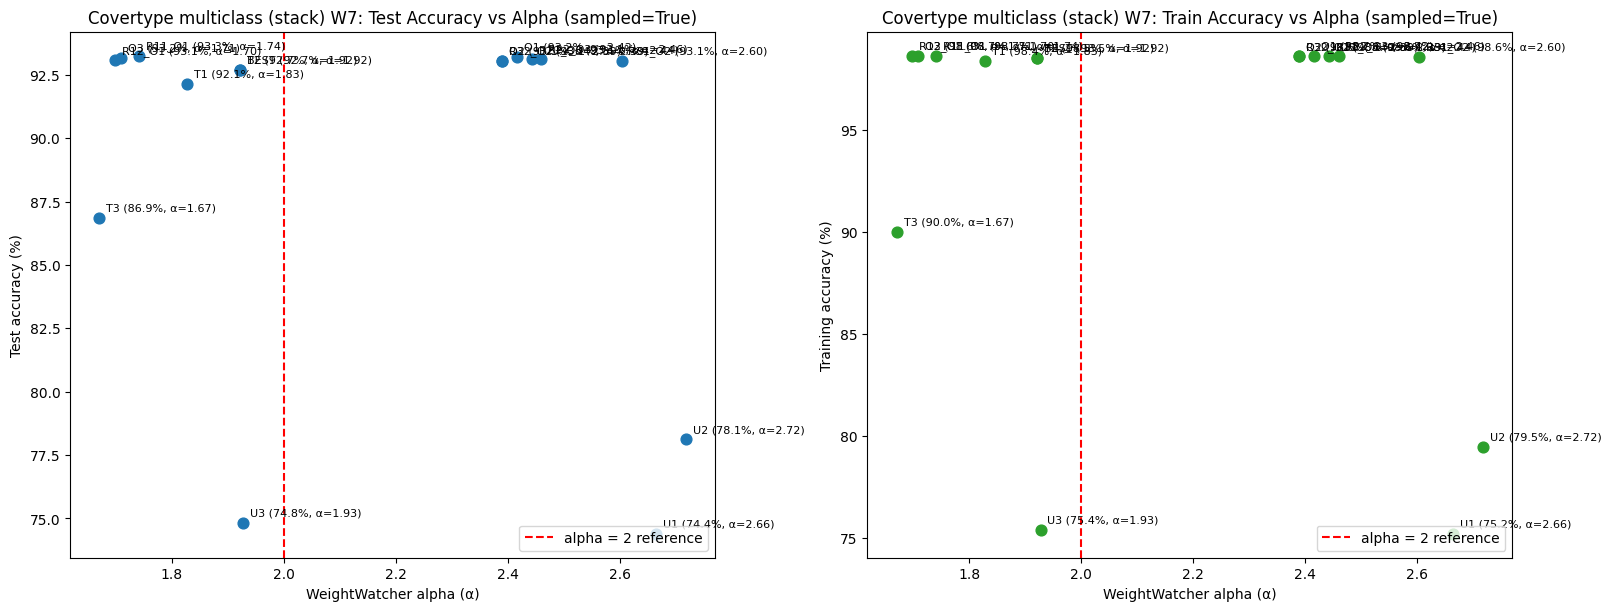

Saved plot: /content/drive/MyDrive/xgboost2ww_checkpoints/covertype_hparam_sweep/covertype_acc_vs_alpha.png


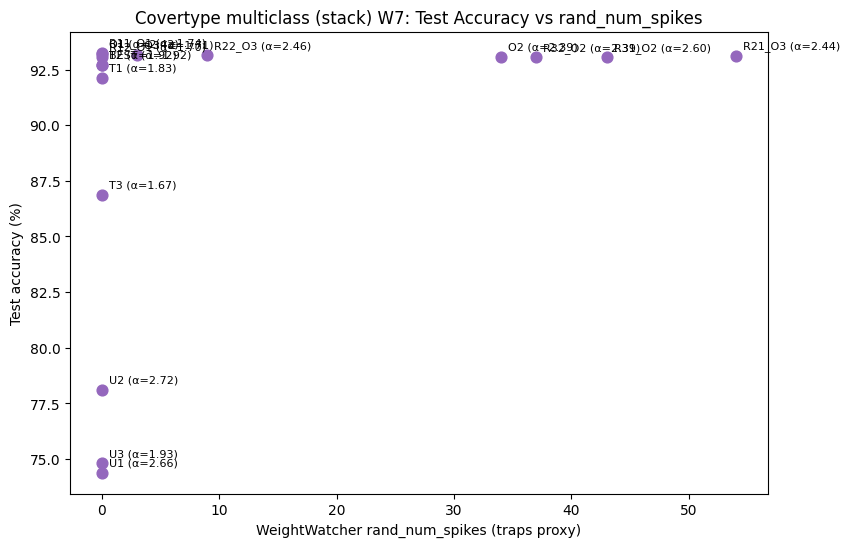

Saved plot: /content/drive/MyDrive/xgboost2ww_checkpoints/covertype_hparam_sweep/covertype_test_vs_rand_num_spikes.png


,tag,test_acc,train_acc,alpha,rand_num_spikes,multiclass_mode,ww_note
0,R11_O1,0.932625,0.986656,1.741002,0.0,stack,
1,O1,0.932083,0.986667,2.415733,0.0,stack,
2,O3,0.931750,0.986354,1.708937,3.0,stack,
3,R22_O3,0.931375,0.986531,2.459738,9.0,stack,
4,R21_O3,0.931292,0.986302,2.443492,54.0,stack,
5,R12_O1,0.930792,0.986615,1.698639,0.0,stack,
6,R31_O2,0.930667,0.986146,2.603029,43.0,stack,
7,O2,0.930583,0.986219,2.389655,34.0,stack,
8,R32_O2,0.930583,0.986219,2.389655,37.0,stack,
9,BEST,0.927125,0.985479,1.921460,0.0,stack,


In [ ]:
plot_df = results.dropna(subset=['alpha']).copy()
plot_df['alpha_line_side'] = np.where(plot_df['alpha'] < 2, 'alpha < 2', 'alpha ≥ 2')

fig, ax = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

ax[0].scatter(plot_df['alpha'], 100*plot_df['test_acc'], s=60)
ax[0].axvline(2.0, color='red', linestyle='--', linewidth=1.5, label='alpha = 2 reference')
for _, r in plot_df.iterrows():
    ax[0].annotate(f"{r['tag']} ({100*r['test_acc']:.1f}%, α={r['alpha']:.2f})", (r['alpha'], 100*r['test_acc']), textcoords='offset points', xytext=(5,5), fontsize=8)
ax[0].set_title(f'Covertype multiclass ({MULTICLASS_MODE_MAIN}) {W_MATRIX_NAME}: Test Accuracy vs Alpha (sampled={USE_SAMPLING})')
ax[0].set_xlabel('WeightWatcher alpha (α)')
ax[0].set_ylabel('Test accuracy (%)')
ax[0].legend(loc='lower right')

ax[1].scatter(plot_df['alpha'], 100*plot_df['train_acc'], s=60, color='tab:green')
ax[1].axvline(2.0, color='red', linestyle='--', linewidth=1.5, label='alpha = 2 reference')
for _, r in plot_df.iterrows():
    ax[1].annotate(f"{r['tag']} ({100*r['train_acc']:.1f}%, α={r['alpha']:.2f})", (r['alpha'], 100*r['train_acc']), textcoords='offset points', xytext=(5,5), fontsize=8)
ax[1].set_title(f'Covertype multiclass ({MULTICLASS_MODE_MAIN}) {W_MATRIX_NAME}: Train Accuracy vs Alpha (sampled={USE_SAMPLING})')
ax[1].set_xlabel('WeightWatcher alpha (α)')
ax[1].set_ylabel('Training accuracy (%)')
ax[1].legend(loc='lower right')

plot_path = CHECKPOINT_DIR / 'covertype_acc_vs_alpha.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print('Saved plot:', plot_path)

trap_fig, trap_ax = plt.subplots(figsize=(9, 6))
trap_ax.scatter(plot_df['rand_num_spikes'], 100*plot_df['test_acc'], s=60, color='tab:purple')
for _, r in plot_df.iterrows():
    trap_ax.annotate(f"{r['tag']} (α={r['alpha']:.2f})", (r['rand_num_spikes'], 100*r['test_acc']), textcoords='offset points', xytext=(5,5), fontsize=8)
trap_ax.set_title(f'Covertype multiclass ({MULTICLASS_MODE_MAIN}) {W_MATRIX_NAME}: Test Accuracy vs rand_num_spikes')
trap_ax.set_xlabel('WeightWatcher rand_num_spikes (traps proxy)')
trap_ax.set_ylabel('Test accuracy (%)')
trap_path = CHECKPOINT_DIR / 'covertype_test_vs_rand_num_spikes.png'
plt.savefig(trap_path, dpi=150)
plt.show()
print('Saved plot:', trap_path)

results[['tag','test_acc','train_acc','alpha','rand_num_spikes','multiclass_mode','ww_note']].sort_values('test_acc', ascending=False)


## Interpretation and takeaways
- Compare underfit/tuned/overfit tags (U*, T*, O*) to verify we captured a broad regime spread.
- Check if top-test-accuracy models cluster near alpha ~2 with fewer spikes versus overfit-leaning configurations.
- Use the saved CSV and PNGs in the checkpoint directory for offline comparison and reproducibility.
- If runtime is tight, keep `USE_SAMPLING=True`; for stronger final estimates, increase `SAMPLE_N` or disable sampling and rerun the best subset.


In [ ]:
plot_df = results.dropna(subset=['alpha']).copy()
plot_df['alpha_line_side'] = np.where(plot_df['alpha'] < 2, 'alpha < 2', 'alpha ≥ 2')
plot_df['has_correlation_trap'] = plot_df['rand_num_spikes'].fillna(0) > 0

# Highlight top test-accuracy model(s) in red across all plots.
top_test_acc = plot_df['test_acc'].max()
plot_df['is_top_test_model'] = np.isclose(plot_df['test_acc'], top_test_acc)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

test_colors = np.where(plot_df['is_top_test_model'], 'red', 'tab:blue')
train_colors = np.where(plot_df['is_top_test_model'], 'red', 'tab:green')

ax[0].scatter(plot_df['alpha'], 100*plot_df['test_acc'], s=60, c=test_colors)
ax[0].axvline(2.0, color='red', linestyle='--', linewidth=1.5, label='alpha = 2 reference')
for _, r in plot_df.iterrows():
    ax[0].annotate(f"{r['tag']} ({100*r['test_acc']:.1f}%, α={r['alpha']:.2f})", (r['alpha'], 100*r['test_acc']), textcoords='offset points', xytext=(5,5), fontsize=8)
ax[0].set_title(f'Covertype multiclass ({MULTICLASS_MODE_MAIN}) {W_MATRIX_NAME}: Test Accuracy vs Alpha (sampled={USE_SAMPLING})')
ax[0].set_xlabel('WeightWatcher alpha (α)')
ax[0].set_ylabel('Test accuracy (%)')
ax[0].set_ylim(bottom=90)
ax[0].legend(loc='lower right')

ax[1].scatter(plot_df['alpha'], 100*plot_df['train_acc'], s=60, c=train_colors)
ax[1].axvline(2.0, color='red', linestyle='--', linewidth=1.5, label='alpha = 2 reference')
for _, r in plot_df.iterrows():
    ax[1].annotate(f"{r['tag']} ({100*r['train_acc']:.1f}%, α={r['alpha']:.2f})", (r['alpha'], 100*r['train_acc']), textcoords='offset points', xytext=(5,5), fontsize=8)
ax[1].set_title(f'Covertype multiclass ({MULTICLASS_MODE_MAIN}) {W_MATRIX_NAME}: Train Accuracy vs Alpha (sampled={USE_SAMPLING})')
ax[1].set_xlabel('WeightWatcher alpha (α)')
ax[1].set_ylabel('Training accuracy (%)')
ax[1].set_ylim(bottom=90)
ax[1].legend(loc='lower right')

plot_path = CHECKPOINT_DIR / 'covertype_acc_vs_alpha.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print('Saved plot:', plot_path)

trap_fig, trap_ax = plt.subplots(figsize=(9, 6))
trap_colors = np.where(plot_df['is_top_test_model'], 'red', 'tab:purple')
trap_ax.scatter(plot_df['rand_num_spikes'], 100*plot_df['test_acc'], s=60, c=trap_colors)
for _, r in plot_df.iterrows():
    trap_ax.annotate(f"{r['tag']} (α={r['alpha']:.2f})", (r['rand_num_spikes'], 100*r['test_acc']), textcoords='offset points', xytext=(5,5), fontsize=8)
trap_ax.set_title(f'Covertype multiclass ({MULTICLASS_MODE_MAIN}) {W_MATRIX_NAME}: Test Accuracy vs rand_num_spikes')
trap_ax.set_xlabel('WeightWatcher rand_num_spikes (traps proxy)')
trap_ax.set_ylabel('Test accuracy (%)')
trap_ax.set_ylim(bottom=90)
trap_path = CHECKPOINT_DIR / 'covertype_test_vs_rand_num_spikes.png'
plt.savefig(trap_path, dpi=150)
plt.show()
print('Saved plot:', trap_path)

# Second set of plots: split by correlation-trap presence.
trap_split_fig, trap_split_ax = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
trap_palette = {False: 'tab:blue', True: 'tab:orange'}
trap_labels = {False: 'without correlation traps', True: 'with correlation traps'}

for has_trap, grp in plot_df.groupby('has_correlation_trap'):
    trap_split_ax[0].scatter(grp['alpha'], 100*grp['test_acc'], s=70, color=trap_palette[has_trap], label=trap_labels[has_trap], alpha=0.9)

# Ensure top models stay red in the split plot too.
top_models = plot_df[plot_df['is_top_test_model']]
trap_split_ax[0].scatter(top_models['alpha'], 100*top_models['test_acc'], s=90, color='red', label='top test accuracy model(s)', zorder=5)

for _, r in plot_df.iterrows():
    trap_split_ax[0].annotate(f"{r['tag']} ({100*r['test_acc']:.1f}%)", (r['alpha'], 100*r['test_acc']), textcoords='offset points', xytext=(5,5), fontsize=8)
trap_split_ax[0].axvline(2.0, color='red', linestyle='--', linewidth=1.5)
trap_split_ax[0].set_title('Test Accuracy vs Alpha (with/without correlation traps)')
trap_split_ax[0].set_xlabel('WeightWatcher alpha (α)')
trap_split_ax[0].set_ylabel('Test accuracy (%)')
trap_split_ax[0].set_ylim(bottom=90)
trap_split_ax[0].legend(loc='lower right')

for has_trap, grp in plot_df.groupby('has_correlation_trap'):
    trap_split_ax[1].scatter(grp['alpha'], 100*grp['train_acc'], s=70, color=trap_palette[has_trap], label=trap_labels[has_trap], alpha=0.9)
trap_split_ax[1].scatter(top_models['alpha'], 100*top_models['train_acc'], s=90, color='red', label='top test accuracy model(s)', zorder=5)
for _, r in plot_df.iterrows():
    trap_split_ax[1].annotate(f"{r['tag']} ({100*r['train_acc']:.1f}%)", (r['alpha'], 100*r['train_acc']), textcoords='offset points', xytext=(5,5), fontsize=8)
trap_split_ax[1].axvline(2.0, color='red', linestyle='--', linewidth=1.5)
trap_split_ax[1].set_title('Train Accuracy vs Alpha (with/without correlation traps)')
trap_split_ax[1].set_xlabel('WeightWatcher alpha (α)')
trap_split_ax[1].set_ylabel('Training accuracy (%)')
trap_split_ax[1].set_ylim(bottom=90)
trap_split_ax[1].legend(loc='lower right')

trap_split_path = CHECKPOINT_DIR / 'covertype_acc_vs_alpha_correlation_trap_split.png'
plt.savefig(trap_split_path, dpi=150)
plt.show()
print('Saved plot:', trap_split_path)

results[['tag','test_acc','train_acc','alpha','rand_num_spikes','has_correlation_trap','multiclass_mode','ww_note']].sort_values('test_acc', ascending=False)

